# Project 4 - NRI Risk Analysis
### Project Designers: Macy Dubes, Arturo Garcia, and Aminasahra Warsame
***Objective:*** Analyze and compare natural hazard risk across Louisiana and Virginia by merging NRI (National Risk Index) data with SVI (Social Vulnerability Index) data, cleaning missing values, and building meaningful risk metrics.

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

print('All packages loaded successfully!')

All packages loaded successfully!


In [2]:
# Load Louisiana NRI and SVI data
la_nri = pd.read_csv('NRI_Table_CensusTracts_Louisiana.csv', low_memory=True)
la_svi = pd.read_csv('Louisiana.csv', low_memory=True)

# Load Virginia NRI and SVI data
va_nri = pd.read_csv('NRI_Table_CensusTracts_Virginia.csv', low_memory=True)
va_svi = pd.read_csv('Virginia.csv', low_memory=True)

# Load the NRI Data Dictionary
nri_dict = pd.read_csv('NRIDataDictionary.csv')

print('All data loaded successfully!')

All data loaded successfully!


In [3]:
la_nri

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,32881,T22001960101,Louisiana,LA,22,Acadia,Parish,1,22001,960101,...,27.779083,Relatively Low,4.499894e-08,4.435997e-09,0.000009,26.933556,371.179942,29.948152,Relatively Low,March 2023
1,32882,T22001960102,Louisiana,LA,22,Acadia,Parish,1,22001,960102,...,25.585410,Relatively Low,4.499894e-08,4.435997e-09,0.000009,29.385584,239.375130,26.493602,Relatively Low,March 2023
2,32883,T22001960201,Louisiana,LA,22,Acadia,Parish,1,22001,960201,...,30.672664,Relatively Low,4.499894e-08,4.435997e-09,0.000009,43.321512,290.235170,27.805261,Relatively Low,March 2023
3,32884,T22001960202,Louisiana,LA,22,Acadia,Parish,1,22001,960202,...,28.387392,Relatively Low,4.499894e-08,4.435997e-09,0.000009,40.992790,209.069338,25.723018,Relatively Low,March 2023
4,32885,T22001960300,Louisiana,LA,22,Acadia,Parish,1,22001,960300,...,30.260469,Relatively Low,4.499894e-08,4.435997e-09,0.000009,39.152594,360.221558,29.647291,Relatively Low,March 2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1371,34252,T22127960100,Louisiana,LA,22,Winn,Parish,127,22127,960100,...,47.105245,Relatively Low,2.281631e-07,1.932709e-08,0.000020,47.483383,1373.780781,48.351805,Relatively Low,March 2023
1372,34253,T22127960201,Louisiana,LA,22,Winn,Parish,127,22127,960201,...,45.044273,Relatively Low,2.281631e-07,1.932709e-08,0.000020,43.781854,1222.088774,46.075727,Relatively Low,March 2023
1373,34254,T22127960202,Louisiana,LA,22,Winn,Parish,127,22127,960202,...,39.843108,Relatively Low,2.281631e-07,1.932709e-08,0.000020,46.650774,879.793414,40.422395,Relatively Low,March 2023
1374,34255,T22127960300,Louisiana,LA,22,Winn,Parish,127,22127,960300,...,38.242478,Relatively Low,2.281631e-07,1.932709e-08,0.000020,38.685206,955.540481,41.697189,Relatively Low,March 2023


In [4]:
va_nri

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,77904,T51001090101,Virginia,VA,51,Accomack,County,1,51001,90101,...,48.773986,Relatively Low,1.391467e-07,5.446982e-08,7.435252e-08,57.425371,1054.050384,43.279979,Relatively Low,March 2023
1,77905,T51001090102,Virginia,VA,51,Accomack,County,1,51001,90102,...,48.388801,Relatively Low,1.378410e-07,6.151782e-08,0.000000e+00,60.146323,1497.155494,49.994054,Relatively Low,March 2023
2,77906,T51001090201,Virginia,VA,51,Accomack,County,1,51001,90201,...,66.881180,Relatively Moderate,1.543765e-07,6.341637e-08,1.214791e-07,62.005308,2919.791114,63.516149,Relatively Moderate,March 2023
3,77907,T51001090202,Virginia,VA,51,Accomack,County,1,51001,90202,...,61.871433,Relatively Moderate,1.610041e-07,6.427677e-08,1.190271e-07,62.044061,2728.676397,62.116491,Relatively Moderate,March 2023
4,77908,T51001090300,Virginia,VA,51,Accomack,County,1,51001,90300,...,54.174789,Relatively Low,1.615276e-07,6.482329e-08,1.210564e-07,62.401062,2065.842831,56.284783,Relatively Low,March 2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2181,80085,T51840000102,Virginia,VA,51,Winchester,City,840,51840,102,...,90.755572,Relatively High,8.550660e-06,1.710406e-07,0.000000e+00,88.220166,23234.337021,94.252723,Relatively High,March 2023
2182,80086,T51840000201,Virginia,VA,51,Winchester,City,840,51840,201,...,92.996219,Relatively High,8.550389e-06,1.710405e-07,0.000000e+00,88.938864,21912.287739,93.783000,Relatively High,March 2023
2183,80087,T51840000202,Virginia,VA,51,Winchester,City,840,51840,202,...,96.702445,Relatively High,8.550994e-06,1.710423e-07,0.000000e+00,89.207788,30441.529434,95.811730,Relatively High,March 2023
2184,80088,T51840000301,Virginia,VA,51,Winchester,City,840,51840,301,...,93.983841,Relatively High,8.551027e-06,1.710433e-07,0.000000e+00,88.391620,29763.478598,95.704704,Relatively High,March 2023


In [5]:
# Louisiana, Create a matching column in the NRI data
la_nri['FIPS'] = la_nri['TRACTFIPS']
la_nri.columns

print(la_svi)

      ST      STATE ST_ABBR  STCNTY         COUNTY         FIPS  \
0     22  Louisiana      LA   22001  Acadia Parish  22001960101   
1     22  Louisiana      LA   22001  Acadia Parish  22001960102   
2     22  Louisiana      LA   22001  Acadia Parish  22001960201   
3     22  Louisiana      LA   22001  Acadia Parish  22001960202   
4     22  Louisiana      LA   22001  Acadia Parish  22001960300   
...   ..        ...     ...     ...            ...          ...   
1374  22  Louisiana      LA   22127    Winn Parish  22127960100   
1375  22  Louisiana      LA   22127    Winn Parish  22127960201   
1376  22  Louisiana      LA   22127    Winn Parish  22127960202   
1377  22  Louisiana      LA   22127    Winn Parish  22127960300   
1378  22  Louisiana      LA   22127    Winn Parish  22127960400   

                                            LOCATION   AREA_SQMI  E_TOTPOP  \
0     Census Tract 9601.01; Acadia Parish; Louisiana    8.816507      3354   
1     Census Tract 9601.02; Acadia Pari

In [19]:
# Merge Louisiana NRI and SVI
la_complete = pd.merge(la_nri, la_svi, on='FIPS', suffixes=('', '_right'))
la_complete.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [20]:
# Virginia: Same merge steps
va_nri['FIPS'] = va_nri['TRACTFIPS']

va_complete = pd.merge(va_nri, va_svi, on='FIPS', suffixes=('', '_right'))
va_complete.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [21]:
# Use .isna() to check for missing values in key columns
print(la_complete.isna())

       OID_  NRI_ID  STATE  STATEABBRV  STATEFIPS  COUNTY  COUNTYTYPE  \
0     False   False  False       False      False   False       False   
1     False   False  False       False      False   False       False   
2     False   False  False       False      False   False       False   
3     False   False  False       False      False   False       False   
4     False   False  False       False      False   False       False   
...     ...     ...    ...         ...        ...     ...         ...   
1371  False   False  False       False      False   False       False   
1372  False   False  False       False      False   False       False   
1373  False   False  False       False      False   False       False   
1374  False   False  False       False      False   False       False   
1375  False   False  False       False      False   False       False   

      COUNTYFIPS  STCOFIPS  TRACT  ...  EP_ASIAN  MP_ASIAN  EP_AIAN  MP_AIAN  \
0          False     False  False  ...     

In [22]:
la_complete_dropped_columns = la_complete.dropna(axis=1)
print(la_complete_dropped_columns)

       OID_        NRI_ID      STATE STATEABBRV  STATEFIPS  COUNTY COUNTYTYPE  \
0     32881  T22001960101  Louisiana         LA         22  Acadia     Parish   
1     32882  T22001960102  Louisiana         LA         22  Acadia     Parish   
2     32883  T22001960201  Louisiana         LA         22  Acadia     Parish   
3     32884  T22001960202  Louisiana         LA         22  Acadia     Parish   
4     32885  T22001960300  Louisiana         LA         22  Acadia     Parish   
...     ...           ...        ...        ...        ...     ...        ...   
1371  34252  T22127960100  Louisiana         LA         22    Winn     Parish   
1372  34253  T22127960201  Louisiana         LA         22    Winn     Parish   
1373  34254  T22127960202  Louisiana         LA         22    Winn     Parish   
1374  34255  T22127960300  Louisiana         LA         22    Winn     Parish   
1375  34256  T22127960400  Louisiana         LA         22    Winn     Parish   

      COUNTYFIPS  STCOFIPS 

In [23]:
# The NRI dataset uses -9999 where data is unavailable
la_complete = la_complete.replace(-9999, np.nan)
va_complete = va_complete.replace(-9999, np.nan)
print('Replaced -9999 with NaN')

Replaced -9999 with NaN


In [24]:
# Fill missing hazard values with 0
hazard_cols = ['HRCN_AFREQ', 'HRCN_EALB', 'CFLD_AFREQ', 'CFLD_EALB', 'TRND_AFREQ', 'TRND_EALB']
la_complete_filled_0 = la_complete.fillna(0)
la_complete[hazard_cols] = la_complete[hazard_cols].fillna(0)
va_complete[hazard_cols] = va_complete[hazard_cols].fillna(0)

print(la_complete_filled_0)

       OID_        NRI_ID      STATE STATEABBRV  STATEFIPS  COUNTY COUNTYTYPE  \
0     32881  T22001960101  Louisiana         LA         22  Acadia     Parish   
1     32882  T22001960102  Louisiana         LA         22  Acadia     Parish   
2     32883  T22001960201  Louisiana         LA         22  Acadia     Parish   
3     32884  T22001960202  Louisiana         LA         22  Acadia     Parish   
4     32885  T22001960300  Louisiana         LA         22  Acadia     Parish   
...     ...           ...        ...        ...        ...     ...        ...   
1371  34252  T22127960100  Louisiana         LA         22    Winn     Parish   
1372  34253  T22127960201  Louisiana         LA         22    Winn     Parish   
1373  34254  T22127960202  Louisiana         LA         22    Winn     Parish   
1374  34255  T22127960300  Louisiana         LA         22    Winn     Parish   
1375  34256  T22127960400  Louisiana         LA         22    Winn     Parish   

      COUNTYFIPS  STCOFIPS 

In [25]:
# Fill missing SVI values with the median as its much more safer
la_complete['RPL_THEMES'] = la_complete['RPL_THEMES'].fillna(la_complete['RPL_THEMES'].median())
va_complete['RPL_THEMES'] = va_complete['RPL_THEMES'].fillna(va_complete['RPL_THEMES'].median())

print('Louisiana median SVI:', round(la_complete['RPL_THEMES'].median(), 3))
print('Virginia median SVI: ', round(va_complete['RPL_THEMES'].median(), 3))

Louisiana median SVI: 0.496
Virginia median SVI:  0.494


In [26]:
# Convert data types
print('Louisiana: Data Types BEFORE conversion')
print(la_complete[['TRACTFIPS', 'POPULATION', 'RISK_SCORE']].dtypes)

la_complete['TRACTFIPS'] = la_complete['TRACTFIPS'].astype(str)
la_complete['POPULATION'] = la_complete['POPULATION'].fillna(0).astype(int)
la_complete['RISK_SCORE'] = la_complete['RISK_SCORE'].astype(float)

va_complete['TRACTFIPS'] = va_complete['TRACTFIPS'].astype(str)
va_complete['POPULATION'] = va_complete['POPULATION'].fillna(0).astype(int)
va_complete['RISK_SCORE'] = va_complete['RISK_SCORE'].astype(float)

print('Louisiana: Data Types AFTER conversion')
print(la_complete[['TRACTFIPS', 'POPULATION', 'RISK_SCORE']].dtypes)

Louisiana: Data Types BEFORE conversion
TRACTFIPS       int64
POPULATION      int64
RISK_SCORE    float64
dtype: object
Louisiana: Data Types AFTER conversion
TRACTFIPS      object
POPULATION      int64
RISK_SCORE    float64
dtype: object


### NRI Risk Definition
> *Risk = Expected Annual Loss × Social Vulnerability ÷ Community Resilience*

We focus on the three hazards most relevant to Louisiana and Virginia: Hurricanes (40%), Coastal Flooding (40%), and Tornadoes (20%). We divide by population for a per-capita view, then multiply by social vulnerability so that small, vulnerable communities are not hidden by larger wealthier ones.

In [27]:
# Louisiana: We create individual hazard risk columns; Risk = Annual Frequency x Expected Annual Loss for Buildings
la_complete['hurricane_risk'] = la_complete['HRCN_AFREQ'] * la_complete['HRCN_EALB']

la_complete['flood_risk']     = la_complete['CFLD_AFREQ'] * la_complete['CFLD_EALB']

la_complete['tornado_risk']   = la_complete['TRND_AFREQ'] * la_complete['TRND_EALB']

print(la_complete['hurricane_risk'], la_complete['flood_risk'], la_complete['tornado_risk'])

0       202503.733153
1        93891.052971
2       173503.015244
3       152656.352674
4       128974.905166
            ...      
1371      3661.125503
1372      2987.113634
1373      4965.763506
1374      2608.113949
1375      1321.801076
Name: hurricane_risk, Length: 1376, dtype: float64 0       0.000000
1       0.000000
2       0.000000
3       0.037168
4       0.626484
          ...   
1371    0.000000
1372    0.000000
1373    0.000000
1374    0.000000
1375    0.000000
Name: flood_risk, Length: 1376, dtype: float64 0         496.017558
1         246.054203
2        3407.415619
3        4462.348465
4        5853.571479
            ...     
1371    28465.087919
1372    10953.146230
1373     9158.518940
1374      182.176915
1375      120.192840
Name: tornado_risk, Length: 1376, dtype: float64


In [28]:
# Louisiana: Build the combined SPCHL score

# Weighted combination; 40% hurricane, 40% flood, 20% tornado
la_complete['combined_risk'] = (0.40 * la_complete['hurricane_risk'] +
                                0.40 * la_complete['flood_risk'] +
                                0.20 * la_complete['tornado_risk'])

la_complete['risk_per_capita'] = la_complete['combined_risk'] / (la_complete['POPULATION'] + 1)

la_complete['my_risk'] = la_complete['risk_per_capita'] * (1 + la_complete['RPL_THEMES'])

la_min = la_complete['my_risk'].min()

la_max = la_complete['my_risk'].max()

la_complete['my_risk_score'] = (la_complete['my_risk'] - la_min) / (la_max - la_min) * 100

print(la_complete['my_risk_score'])

0       99.969744
1       99.969715
2       99.969713
3       99.969716
4       99.969702
          ...    
1371    99.969677
1372    99.969675
1373    99.969677
1374    99.969674
1375    99.969674
Name: my_risk_score, Length: 1376, dtype: float64


In [29]:
# Louisiana: Assign risk rating category using the same 5 labels as the NRI
la_q20 = la_complete['my_risk_score'].quantile(0.20)
la_q40 = la_complete['my_risk_score'].quantile(0.40)
la_q60 = la_complete['my_risk_score'].quantile(0.60)
la_q80 = la_complete['my_risk_score'].quantile(0.80)

la_complete['my_risk_rating'] = 'Relatively Moderate'

la_complete.loc[la_complete['my_risk_score'] <= la_q20, 'my_risk_rating'] = 'Very Low'

la_complete.loc[(la_complete['my_risk_score'] > la_q20) & (la_complete['my_risk_score'] <= la_q40), 'my_risk_rating'] = 'Relatively Low'
la_complete.loc[(la_complete['my_risk_score'] > la_q60) & (la_complete['my_risk_score'] <= la_q80), 'my_risk_rating'] = 'Relatively High'

la_complete.loc[la_complete['my_risk_score'] > la_q80, 'my_risk_rating'] = 'Very High'

print('Louisiana: Our Risk Rating Distribution')
print(la_complete['my_risk_rating'].value_counts())
print('Louisiana: NRI Risk Rating Distribution')
print(la_complete['RISK_RATNG'].value_counts())

Louisiana: Our Risk Rating Distribution
my_risk_rating
Very Low               276
Relatively High        275
Relatively Moderate    275
Relatively Low         275
Very High              275
Name: count, dtype: int64
Louisiana: NRI Risk Rating Distribution
RISK_RATNG
Relatively High        449
Relatively Moderate    431
Relatively Low         311
Very High              149
Very Low                36
Name: count, dtype: int64


In [30]:
# Virginia: Create risk columns, somewhat same steps as Louisiana
va_complete['hurricane_risk'] = va_complete['HRCN_AFREQ'] * va_complete['HRCN_EALB']
va_complete['flood_risk']     = va_complete['CFLD_AFREQ'] * va_complete['CFLD_EALB']
va_complete['tornado_risk']   = va_complete['TRND_AFREQ'] * va_complete['TRND_EALB']
va_complete['combined_risk']   = (0.40 * va_complete['hurricane_risk'] +
                                  0.40 * va_complete['flood_risk'] +
                                  0.20 * va_complete['tornado_risk'])

va_complete['risk_per_capita'] = va_complete['combined_risk'] / (va_complete['POPULATION'] + 1)

va_complete['my_risk'] = va_complete['risk_per_capita'] * (1 + va_complete['RPL_THEMES'])

va_min = va_complete['my_risk'].min()
va_max = va_complete['my_risk'].max()

va_complete['my_risk_score'] = (va_complete['my_risk'] - va_min) / (va_max - va_min) * 100

va_q20 = va_complete['my_risk_score'].quantile(0.20)
va_q40 = va_complete['my_risk_score'].quantile(0.40)
va_q60 = va_complete['my_risk_score'].quantile(0.60)
va_q80 = va_complete['my_risk_score'].quantile(0.80)

va_complete['my_risk_rating'] = 'Relatively Moderate'

va_complete.loc[va_complete['my_risk_score'] <= va_q20, 'my_risk_rating'] = 'Very Low'
va_complete.loc[(va_complete['my_risk_score'] > va_q20) & (va_complete['my_risk_score'] <= va_q40), 'my_risk_rating'] = 'Relatively Low'
va_complete.loc[(va_complete['my_risk_score'] > va_q60) & (va_complete['my_risk_score'] <= va_q80), 'my_risk_rating'] = 'Relatively High'
va_complete.loc[va_complete['my_risk_score'] > va_q80, 'my_risk_rating'] = 'Very High'

print('Virginia: Our Risk Rating Distribution')
print(va_complete['my_risk_rating'].value_counts())
print('Virginia: NRI Risk Rating Distribution')
print(va_complete['RISK_RATNG'].value_counts())

Virginia: Our Risk Rating Distribution
my_risk_rating
Very Low               438
Very High              437
Relatively Low         437
Relatively Moderate    437
Relatively High        437
Name: count, dtype: int64
Virginia: NRI Risk Rating Distribution
RISK_RATNG
Very Low               1005
Relatively Low          855
Relatively Moderate     262
Relatively High          59
Very High                 5
Name: count, dtype: int64


In [34]:
# Group Louisiana data by county
grouped_la = la_complete.groupby('COUNTY', as_index=False)

# Run summary mean by county
grouped_la = la_complete.groupby('COUNTY').agg(
    mean_nri_score = ('RISK_SCORE',    'mean'),
    mean_my_score  = ('my_risk_score', 'mean'),
    mean_svi       = ('RPL_THEMES',    'mean'),
    total_pop      = ('POPULATION',    'sum')
).round(2)

print(grouped_la)

                  mean_nri_score  mean_my_score  mean_svi  total_pop
COUNTY                                                              
Acadia                     82.60          99.97      0.51      57475
Allen                      72.65          99.97      0.54      22708
Ascension                  95.52          99.97      0.31     126426
Assumption                 94.78          99.97      0.52      21017
Avoyelles                  81.88          99.97      0.68      39654
...                          ...            ...       ...        ...
Webster                    46.43          99.97      0.57      36954
West Baton Rouge           80.76          99.97      0.46      27101
West Carroll               76.76          99.97      0.57       9736
West Feliciana             45.23          99.96   -142.49      15300
Winn                       52.08          99.97      0.55      13718

[64 rows x 4 columns]


In [35]:
# Group Virginia data by county
grouped_va = va_complete.groupby('COUNTY', as_index=False)

# Run summary mean by county
grouped_va = va_complete.groupby('COUNTY').agg(
    mean_nri_score = ('RISK_SCORE',    'mean'),
    mean_my_score  = ('my_risk_score', 'mean'),
    mean_svi       = ('RPL_THEMES',    'mean'),
    total_pop      = ('POPULATION',    'sum')
).round(2)

print(grouped_va)

              mean_nri_score  mean_my_score  mean_svi  total_pop
COUNTY                                                          
Accomack               81.10          95.43    -76.22      33367
Albemarle              31.74          99.99      0.41     112239
Alexandria             22.25          99.98    -20.40     159467
Alleghany              32.38          99.99      0.49      15205
Amelia                 44.87          99.99      0.63      13265
...                      ...            ...       ...        ...
Williamsburg           76.33          99.99      0.55      15425
Winchester             49.16          99.99      0.84      28110
Wise                   37.20          99.99      0.75      36104
Wythe                  15.15          99.99      0.57      28279
York                   69.90          99.99      0.35      70026

[129 rows x 4 columns]


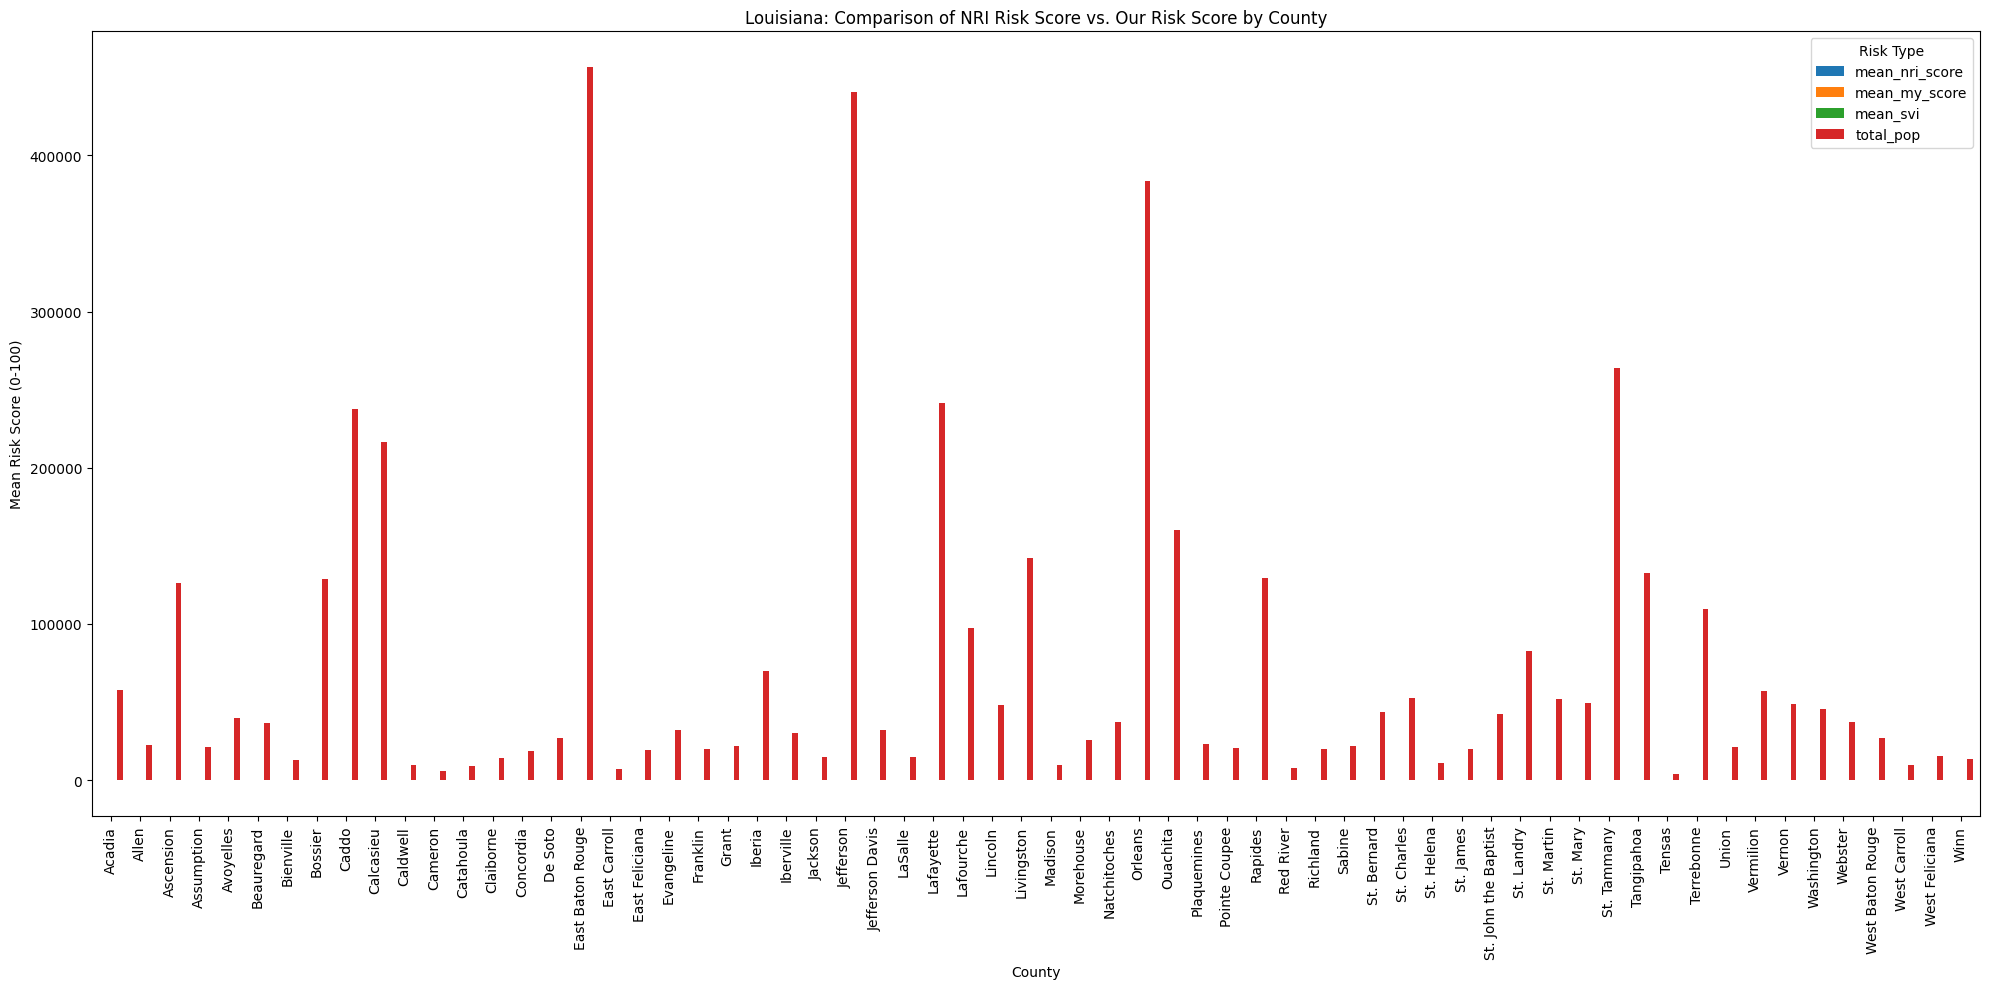

In [36]:
# Create bar plot with side-by-side bars — Louisiana
grouped_la.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('County')
plt.ylabel('Mean Risk Score (0-100)')
plt.title('Louisiana: Comparison of NRI Risk Score vs. Our Risk Score by County')
plt.xticks(rotation=90)

plt.legend(title='Risk Type')
plt.tight_layout()

plt.show()

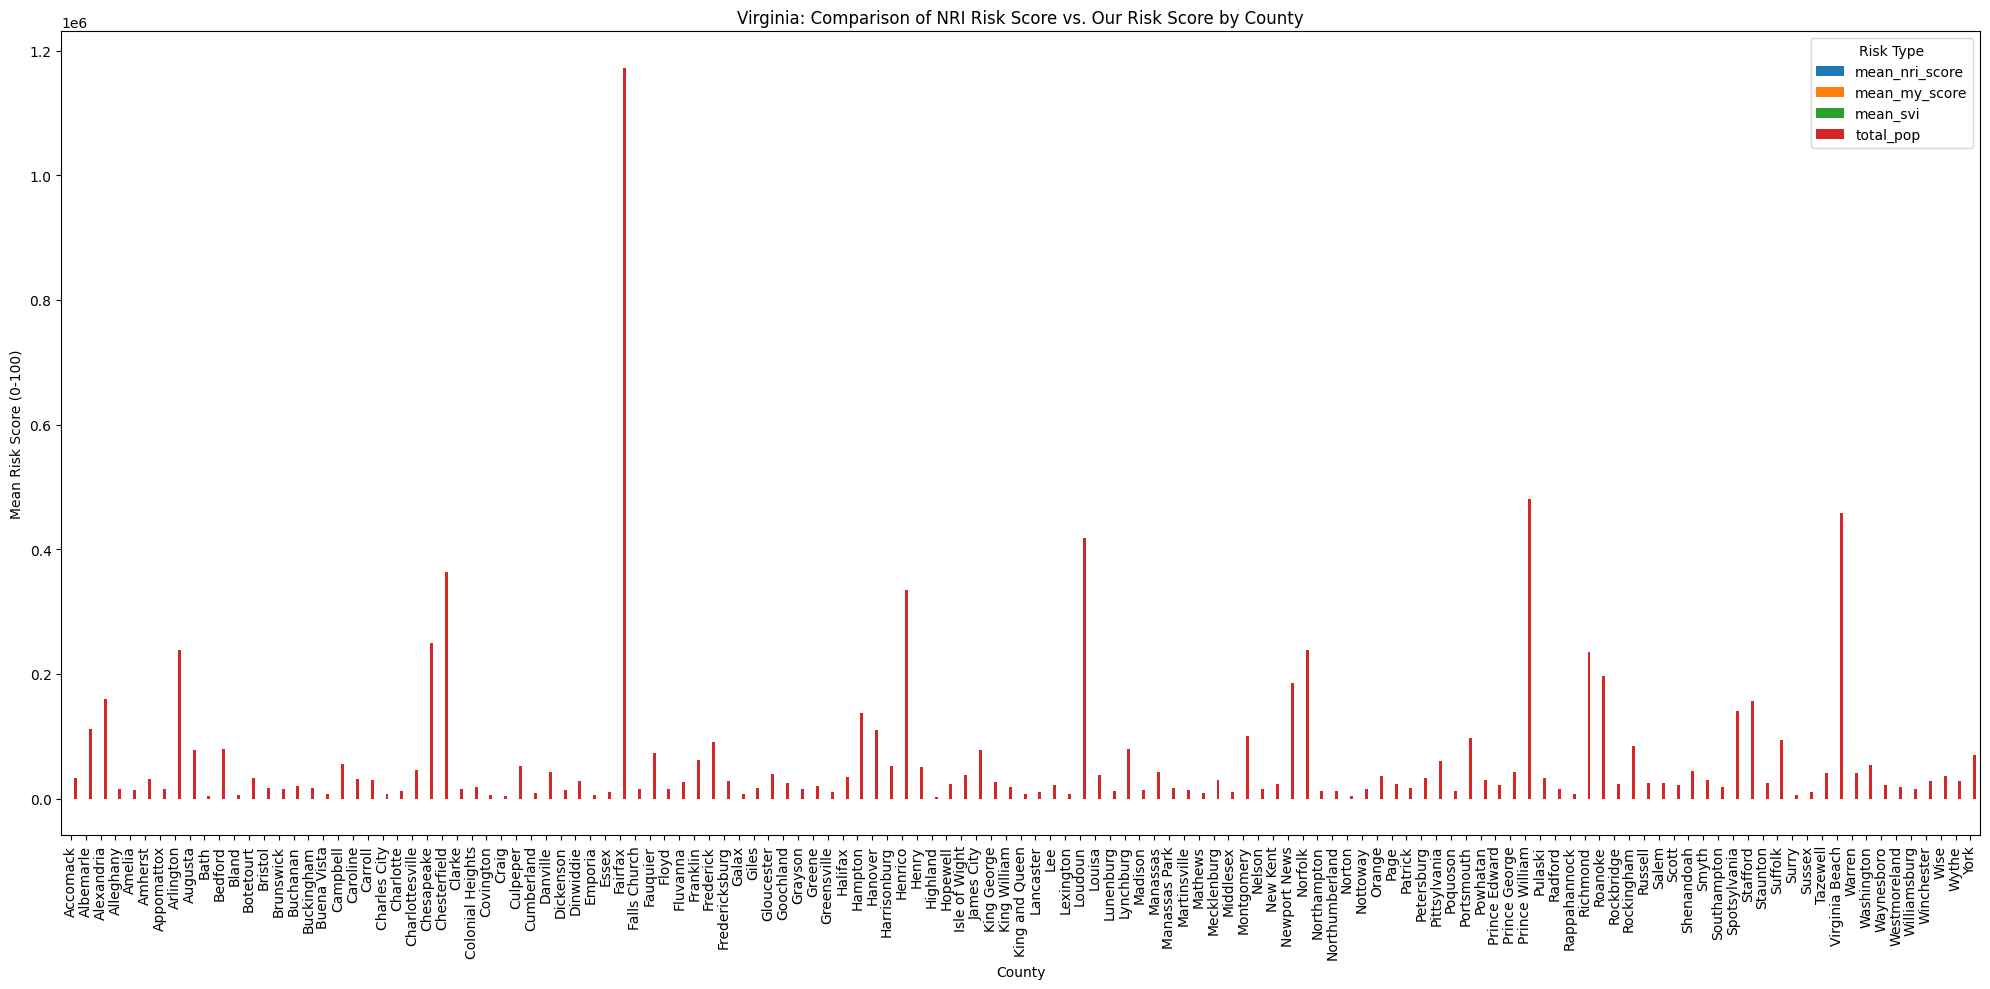

In [38]:
# Create bar plot with side-by-side bars — Virginia
grouped_va.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('County')
plt.ylabel('Mean Risk Score (0-100)')
plt.title('Virginia: Comparison of NRI Risk Score vs. Our Risk Score by County')
plt.xticks(rotation=90)

plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

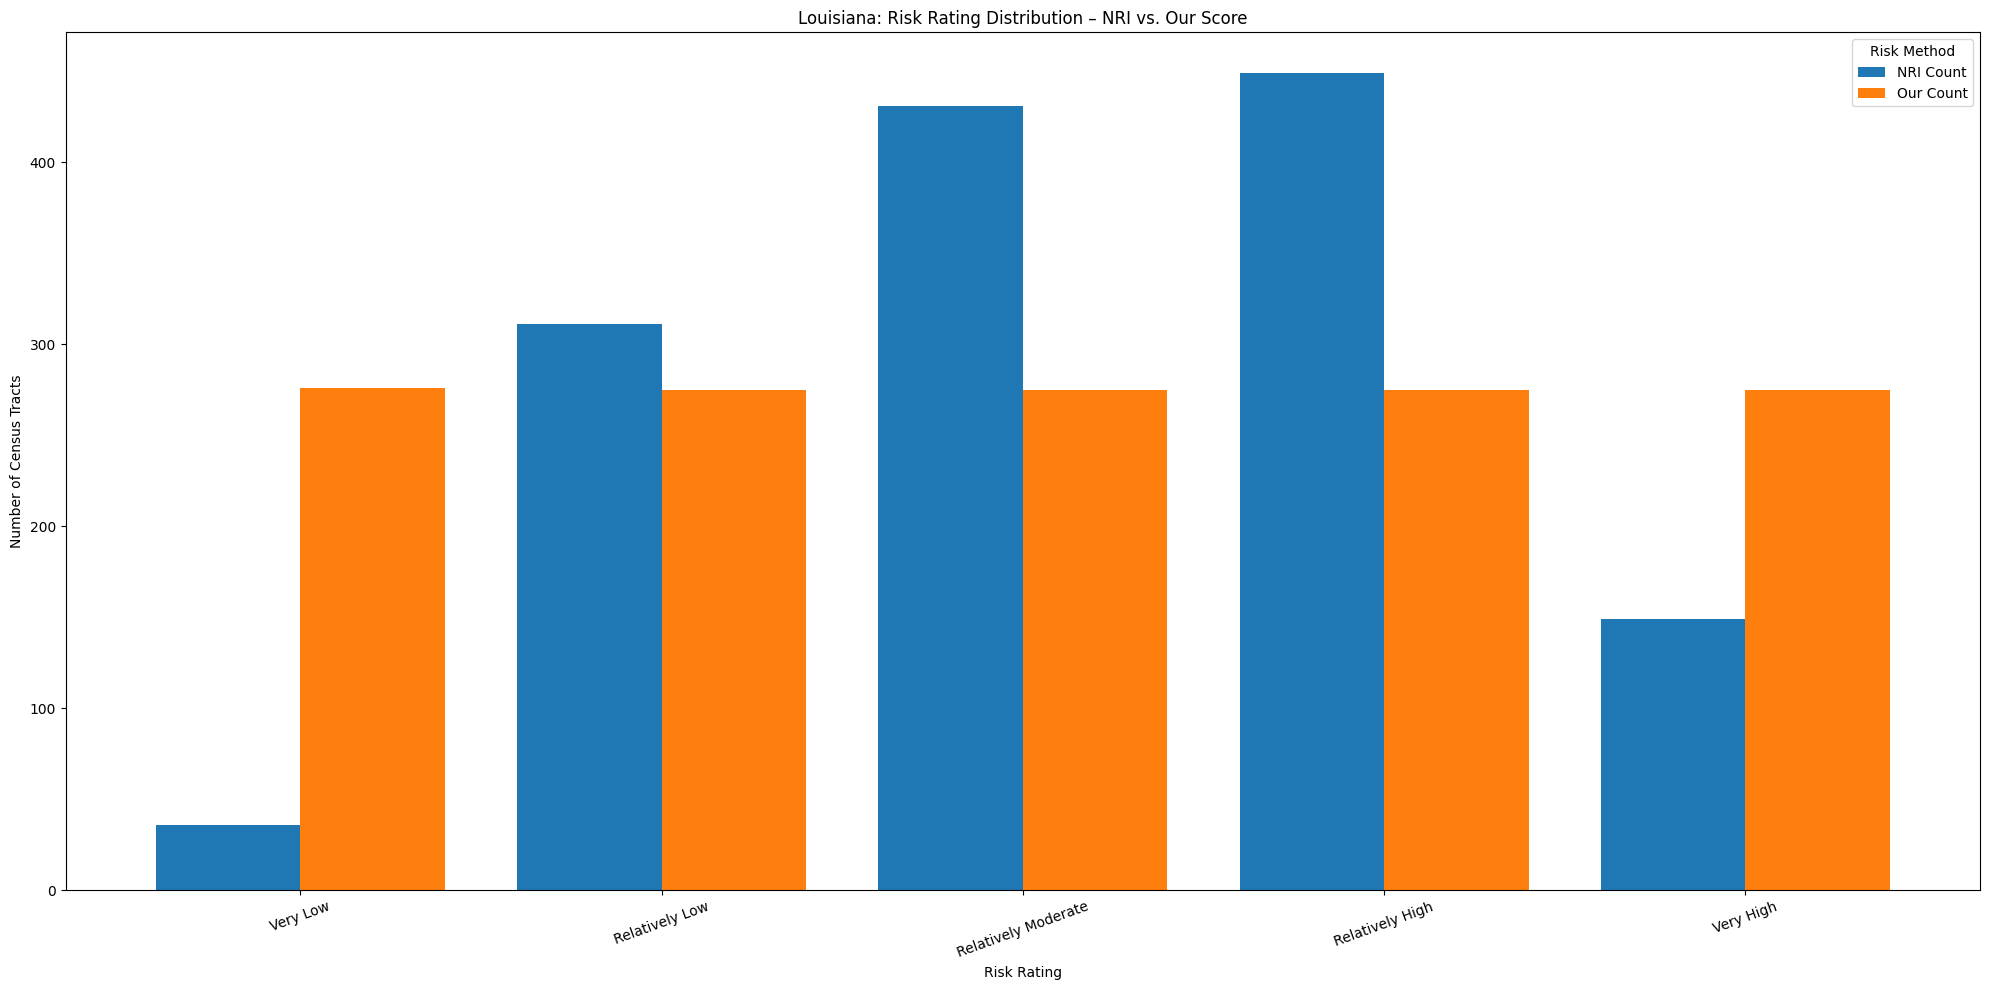

In [39]:
# Louisiana: Rating Distribution Comparison
rating_order = ['Very Low', 'Relatively Low', 'Relatively Moderate', 'Relatively High', 'Very High']

la_rating_summary = la_complete.groupby('RISK_RATNG').size().reindex(rating_order, fill_value=0).rename('NRI Count').to_frame()
la_rating_summary['Our Count'] = la_complete.groupby('my_risk_rating').size().reindex(rating_order, fill_value=0).values

la_rating_summary.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('Risk Rating')
plt.ylabel('Number of Census Tracts')
plt.title('Louisiana: Risk Rating Distribution – NRI vs. Our Score')
plt.xticks(rotation=20)
plt.legend(title='Risk Method')
plt.tight_layout()
plt.show()

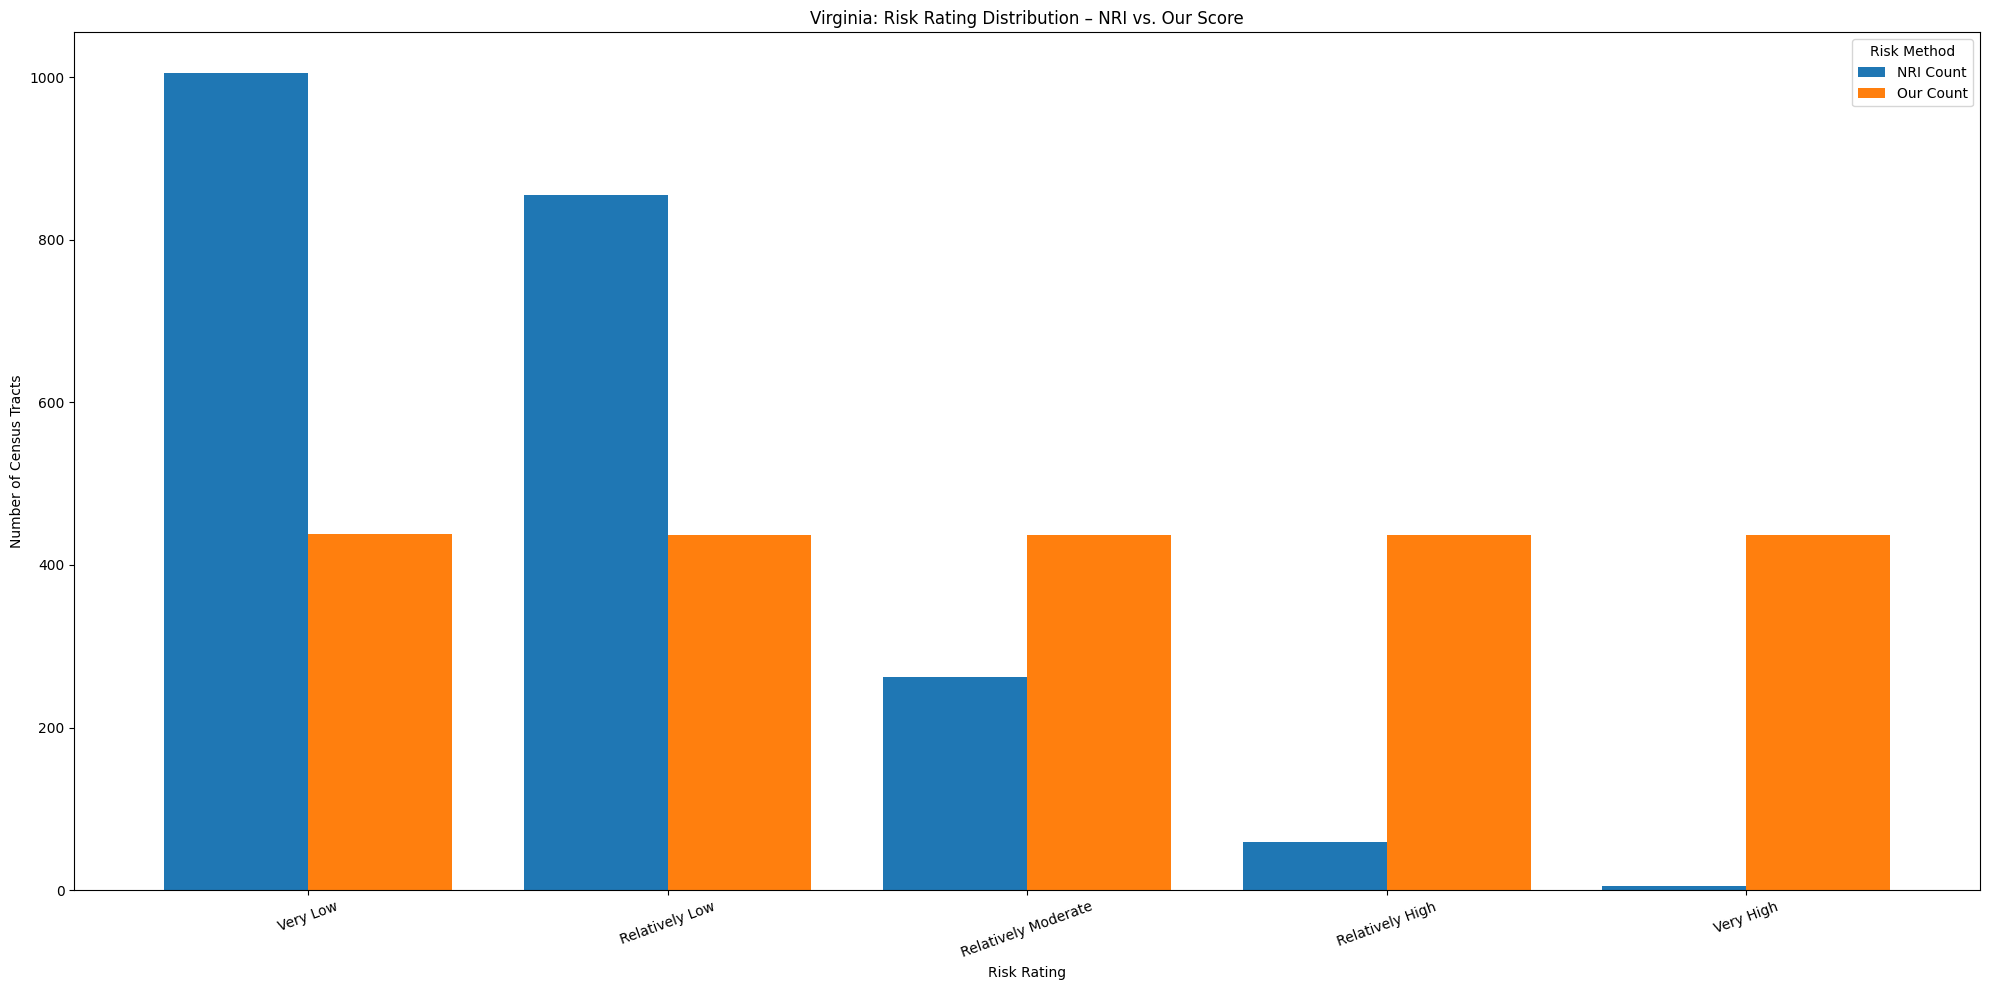

In [40]:
# Virginia: Rating Distribution Comparison
va_rating_summary = va_complete.groupby('RISK_RATNG').size().reindex(rating_order, fill_value=0).rename('NRI Count').to_frame()
va_rating_summary['Our Count'] = va_complete.groupby('my_risk_rating').size().reindex(rating_order, fill_value=0).values

va_rating_summary.plot(kind='bar', figsize=(20, 10), width=0.8)

plt.xlabel('Risk Rating')
plt.ylabel('Number of Census Tracts')
plt.title('Virginia: Risk Rating Distribution – NRI vs. Our Score')
plt.xticks(rotation=20)
plt.legend(title='Risk Method')
plt.tight_layout()
plt.show()

*Maps:*
1. Louisiana – NRI Risk Score
2. Louisiana – Our Risk Rating
3. Virginia – NRI Risk Score
4. Virginia – Our Risk Rating

In [41]:
# Read the Census Tracts shapefile
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
tracts.head()
tracts.crs
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

In [57]:
# Cleaning data
tracts_clean = tracts.set_crs(epsg=4326, inplace=True, allow_override=True)

tracts_clean = tracts_clean.to_crs(epsg=4326)

tracts_clean = tracts_clean.replace(-9999, np.nan)

#Checking the data
print(tracts_clean.crs)
print(tracts_clean.geometry.head())

EPSG:4326
0    POLYGON ((-9626784.4931 3827718.7744, -9626802...
1    POLYGON ((-9625497.973 3827700.4302, -9625504....
2    POLYGON ((-9623646.6171 3823891.9919, -9623666...
3    POLYGON ((-9622012.0009 3826514.0386, -9622007...
4    POLYGON ((-9619304.7093 3823820.3533, -9619304...
Name: geometry, dtype: geometry


In [58]:
tracts_clean.crs = 'EPSG:3857'
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.to_crs('ESRI:102003')

In [59]:
# Merge our risk scores into the shapefile
tracts_clean['TRACTFIPS'] = tracts_clean['TRACTFIPS'].astype(str)

# Merge Louisiana scores
la_scores = la_complete[['TRACTFIPS', 'my_risk_score', 'my_risk_rating']]
tracts_clean = pd.merge(tracts_clean, la_scores, on='TRACTFIPS', how='left')

# Merge Virginia scores
va_scores = va_complete[['TRACTFIPS', 'my_risk_score', 'my_risk_rating']]
tracts_clean = pd.merge(tracts_clean, va_scores, on='TRACTFIPS', how='left', suffixes=('', '_va'))

# Combine: use Virginia values where Louisiana values are blank
tracts_clean['my_risk_score']  = tracts_clean['my_risk_score'].fillna(tracts_clean['my_risk_score_va'])
tracts_clean['my_risk_rating'] = tracts_clean['my_risk_rating'].fillna(tracts_clean['my_risk_rating_va'])

print(tracts_clean)

             NRI_ID           STATE STATEABBRV STATEFIPS      COUNTY  \
0      T01001020100         Alabama         AL        01     Autauga   
1      T01001020200         Alabama         AL        01     Autauga   
2      T01001020300         Alabama         AL        01     Autauga   
3      T01001020400         Alabama         AL        01     Autauga   
4      T01001020501         Alabama         AL        01     Autauga   
...             ...             ...        ...       ...         ...   
85149  T78030960800  Virgin Islands         VI        78  St. Thomas   
85150  T78030960900  Virgin Islands         VI        78  St. Thomas   
85151  T78030961000  Virgin Islands         VI        78  St. Thomas   
85152  T78030961100  Virgin Islands         VI        78  St. Thomas   
85153  T78030961200  Virgin Islands         VI        78  St. Thomas   

      COUNTYTYPE COUNTYFIPS STCOFIPS   TRACT    TRACTFIPS  ...  WNTW_RISKS  \
0         County        001    01001  020100  01001020100

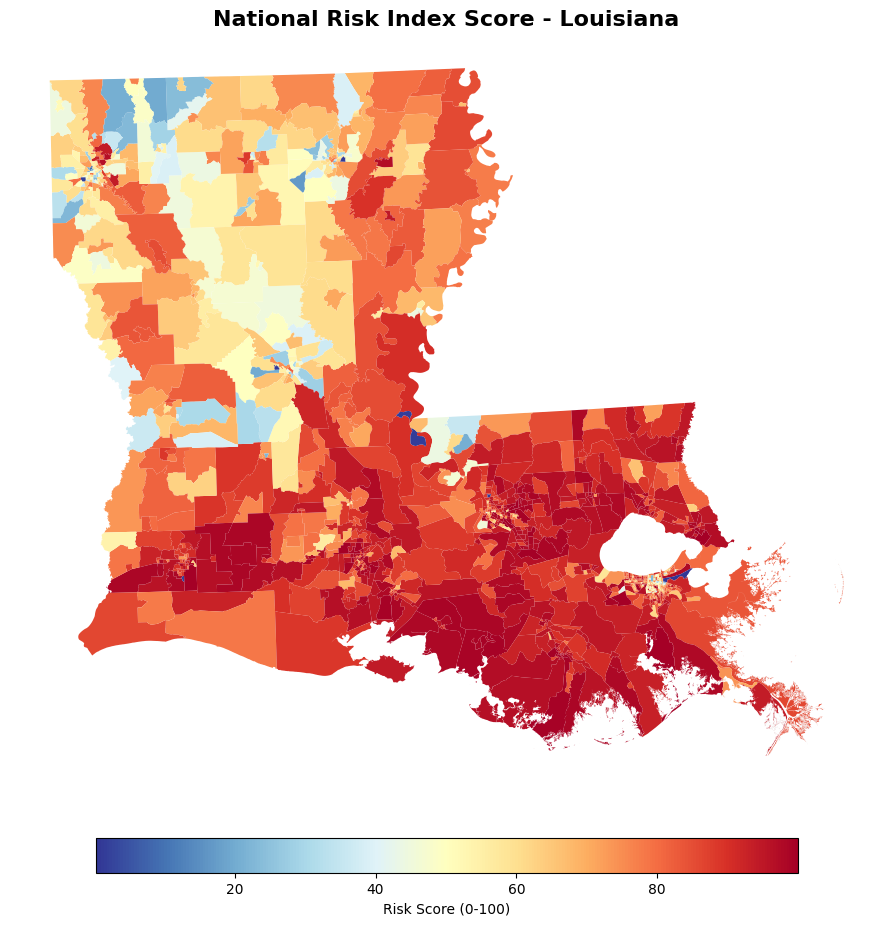

In [60]:
# Map 1: Louisiana – NRI Risk Score
state_name = 'Louisiana'
la_map = tracts_clean[tracts_clean['STATE'].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
la_map.plot(
    column='RISK_SCORE',
    cmap='RdYlBu_r',
    aspect=1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)
ax.set_title(f'National Risk Index Score - {state_name}', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\agarc\AppData\Local\Temp\ipykernel_38608\2816650723.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Risk Rating', loc='lower left', fontsize=9)
C:\Users\agarc\AppData\Local\Temp\ipykernel_38608\2816650723.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Risk Rating', loc='lower left', fontsize=9)


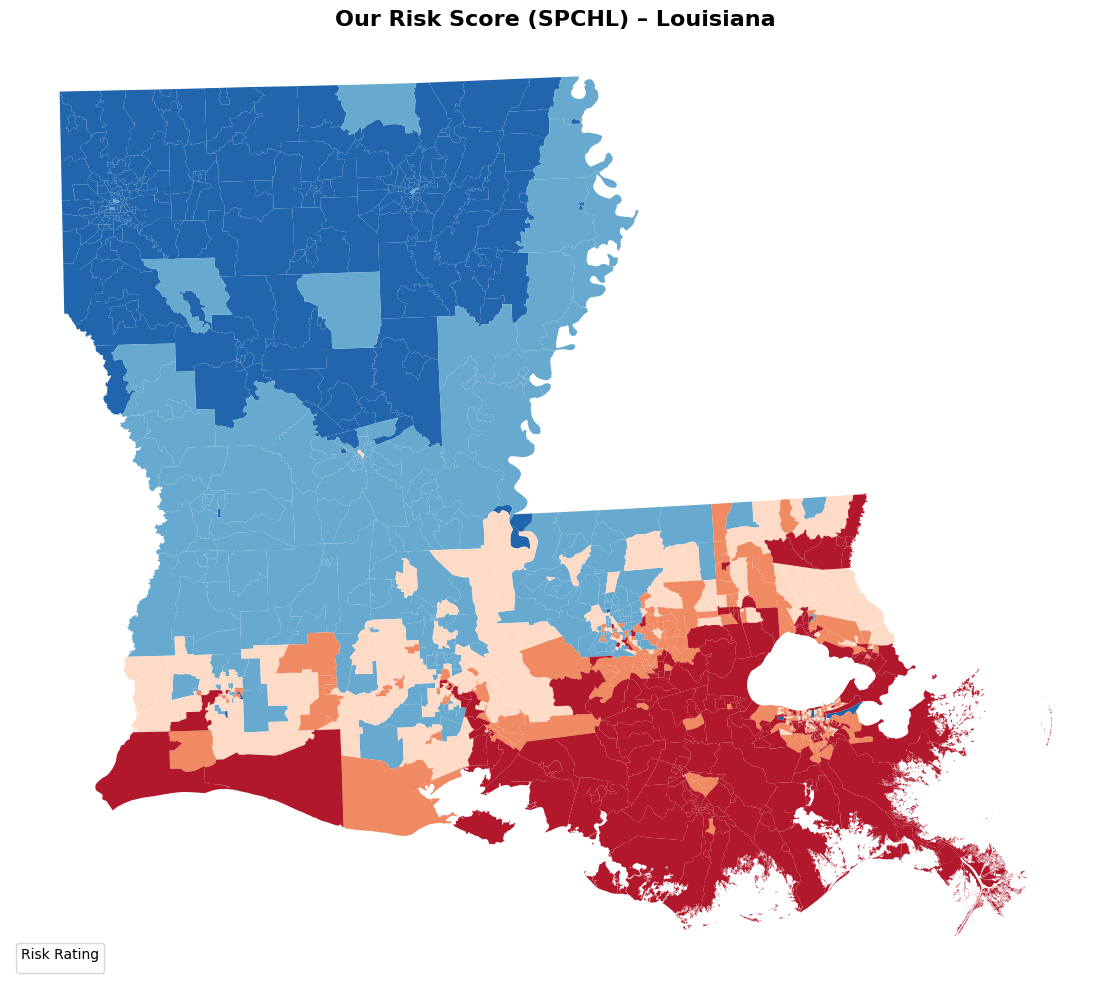

In [61]:
# Map 2: Louisiana – Our Risk Rating

rating_order = ['Very Low', 'Relatively Low', 'Relatively Moderate', 'Relatively High', 'Very High']
rating_colors = {
    'Very Low':           '#2166ac',
    'Relatively Low':     '#67a9cf',
    'Relatively Moderate':'#fddbc7',
    'Relatively High':    '#ef8a62',
    'Very High':          '#b2182b',
}

rated_la = la_map[la_map['my_risk_rating'].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
for rating in rating_order:
    subset = rated_la[rated_la['my_risk_rating'] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

ax.legend(title='Risk Rating', loc='lower left', fontsize=9)
ax.set_title('Our Risk Score (SPCHL) – Louisiana', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

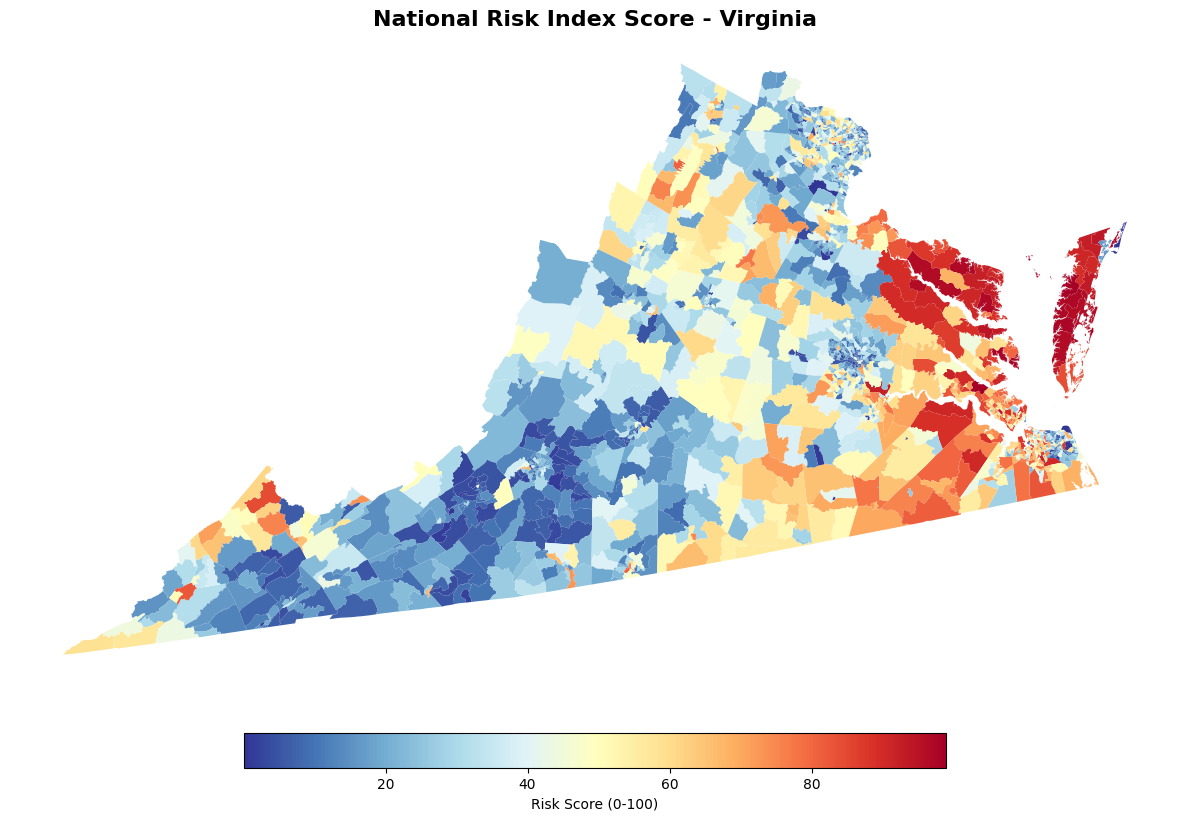

In [62]:
# Map 3: Virginia – NRI Risk Score
state_name = 'Virginia'
va_map = tracts_clean[tracts_clean['STATE'].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
va_map.plot(
    column='RISK_SCORE',
    cmap='RdYlBu_r',
    aspect=1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)
ax.set_title(f'National Risk Index Score - {state_name}', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\agarc\AppData\Local\Temp\ipykernel_38608\1240467463.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Risk Rating', loc='lower left', fontsize=9)
C:\Users\agarc\AppData\Local\Temp\ipykernel_38608\1240467463.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Risk Rating', loc='lower left', fontsize=9)


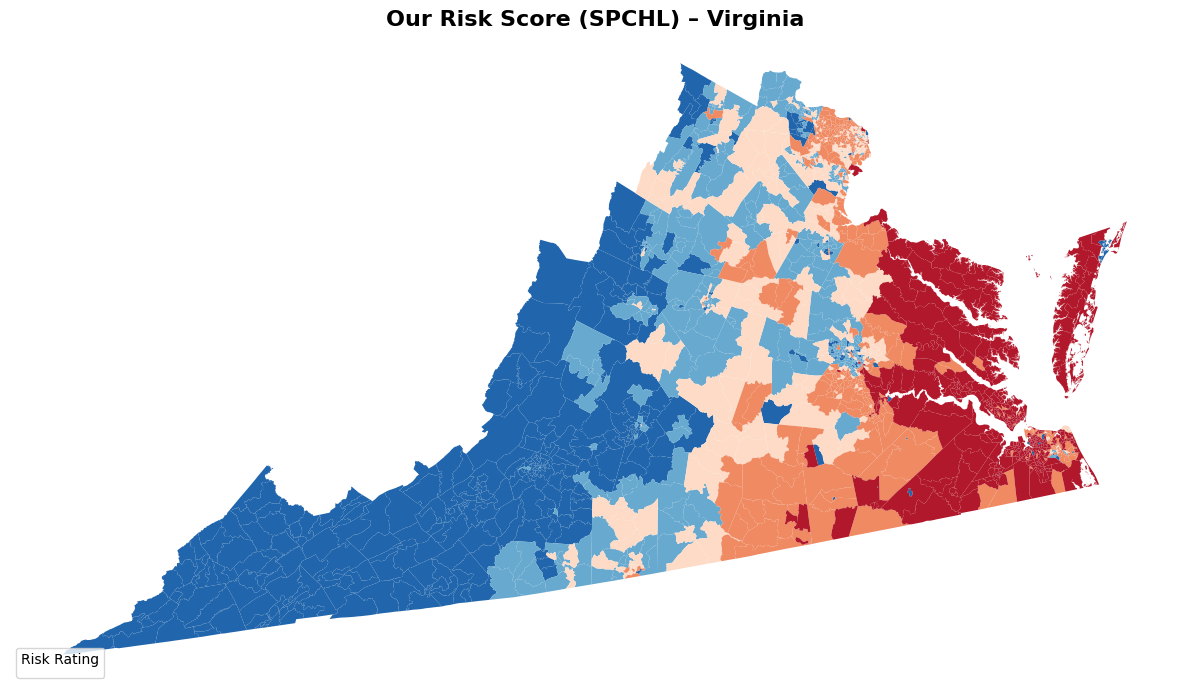

In [63]:
# Map 4: Virginia – Our Risk Rating

rated_va = va_map[va_map['my_risk_rating'].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
for rating in rating_order:
    subset = rated_va[rated_va['my_risk_rating'] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

ax.legend(title='Risk Rating', loc='lower left', fontsize=9)
ax.set_title('Our Risk Score (SPCHL) – Virginia', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [64]:
# Exporting the Louisiana and Virginia cleaned and scored data

export_cols = ['TRACTFIPS', 'STATE', 'COUNTY', 'POPULATION',
               'RISK_SCORE', 'RISK_RATNG',
               'hurricane_risk', 'flood_risk', 'tornado_risk',
               'my_risk_score', 'my_risk_rating', 'RPL_THEMES']

la_complete[export_cols].to_csv('Project4_Cleaned_Louisiana.csv', index=False)
va_complete[export_cols].to_csv('Project4_Cleaned_Virginia.csv', index=False)

print('Louisiana data exported:', len(la_complete), 'rows')
print('Virginia data exported: ', len(va_complete), 'rows')

Louisiana data exported: 1376 rows
Virginia data exported:  2186 rows
